In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [37]:
def plot_vectors(vs, cs=None, ax=None):
    if ax is None:
        ax = plt.gca() # get current ax of figure
    if cs is None:
        cs = ['red', 'blue', 'yellow', 'orange', 'green', 'purple', 'c', 'm', 'brown']
    for v, c in zip(vs,cs):
        ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy',scale=1, color=c)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_aspect('equal')
    ax.set_xlim(-5,5)
    ax.set_ylim(-5,5)


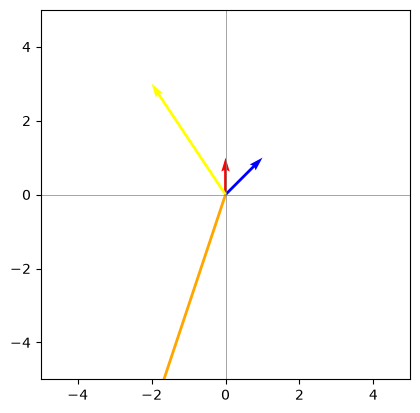

In [38]:
fig = plt.figure()
ax = fig.add_subplot()

plot_vectors([[0,1], [1,1], [-2, 3], [-2, -6]])

/tmp/ipykernel_6159/560412844.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


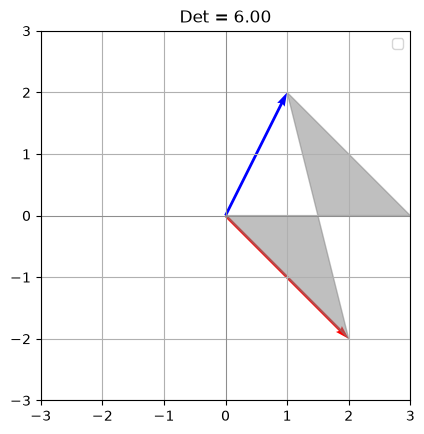

In [50]:
def det_2d(A):
    det = np.linalg.det(A)
    
    v1, v2 = A[:,0], A[:,1]
    plot_vectors([v1,v2])
    vs = [[0,0], v1, v2, v1+v2]
    poly = plt.Polygon(vs, color='gray', alpha=0.5)
    ax = plt.gca()
    ax.add_patch(poly)

    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_aspect('equal'); ax.grid(True)
    ax.legend()def parallelepiped_3d(A):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    origin = np.zeros(3)
    colors = ['r','g','b']
    # Plot column vectors
    for i in range(3):
        ax.quiver(*origin, *A[:,i], color=colors[i], arrow_length_ratio=0.1)
    
    # Build all 8 corners
    c = [np.zeros(3), A[:,0], A[:,1], A[:,0]+A[:,1],
         A[:,2], A[:,0]+A[:,2], A[:,1]+A[:,2], A[:,0]+A[:,1]+A[:,2]]
    # Connect edges of parallelepiped
    edges = [(0,1), (0,2), (0,4), (1,3), (1,5), (2,3), (2,6), (3,7),
             (4,5), (4,6), (5,7), (6,7)]
    for s,e in edges:
        ax.plot(*zip(c[s], c[e]), color='k')
    
    det = np.linalg.det(A)
    ax.set_title(f'Volume = |det| = {abs(det):.2f}')
    ax.set_xlim(-3,3); ax.set_ylim(-3,3); ax.set_zlim(-3,3)
    plt.show()

# Example: shear + scale
A3 = np.array([[2,0.5,0.3],
               [0,1.5,0.4],
               [0,0,1.2]])
parallelepiped_3d(A3)
    ax.set_title(f'Det = {det:.2f}')
    plt.show()
    
det_2d(np.array([[2,1], [-2, 2]]))

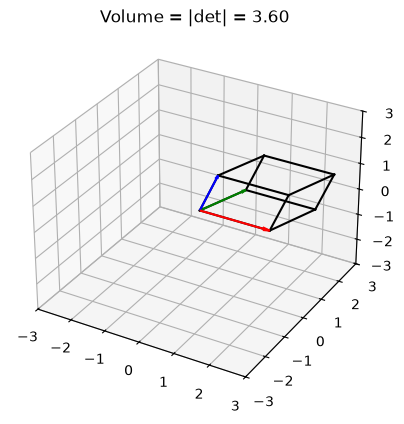

In [52]:
def parallelepiped_3d(A):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    origin = np.zeros(3)
    colors = ['r','g','b']
    # Plot column vectors
    for i in range(3):
        ax.quiver(*origin, *A[:,i], color=colors[i], arrow_length_ratio=0.1)
    
    # Build all 8 corners
    c = [np.zeros(3), A[:,0], A[:,1], A[:,0]+A[:,1],
         A[:,2], A[:,0]+A[:,2], A[:,1]+A[:,2], A[:,0]+A[:,1]+A[:,2]]
    # Connect edges of parallelepiped
    edges = [(0,1), (0,2), (0,4), (1,3), (1,5), (2,3), (2,6), (3,7),
             (4,5), (4,6), (5,7), (6,7)]
    for s,e in edges:
        ax.plot(*zip(c[s], c[e]), color='k')
    
    det = np.linalg.det(A)
    ax.set_title(f'Volume = |det| = {abs(det):.2f}')
    ax.set_xlim(-3,3); ax.set_ylim(-3,3); ax.set_zlim(-3,3)
    plt.show()

# Example: shear + scale
A3 = np.array([[2,0.5,0.3],
               [0,1.5,0.4],
               [0,0,1.2]])
parallelepiped_3d(A3)

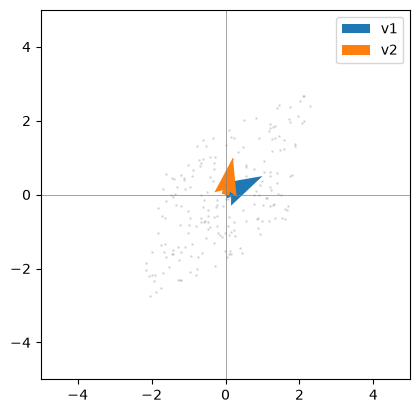

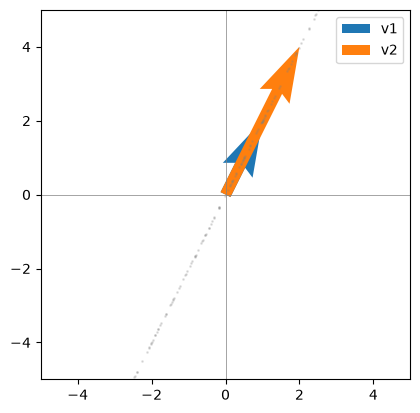

In [51]:
def span_2d(vectors, num_samples=200):
    fig, ax = plt.subplots()
    # Plot original vectors
    for i, v in enumerate(vectors):
        ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
                  color=f'C{i}', width=0.03, label=f'v{i+1}')
    # Generate linear combinations
    coeffs = np.random.uniform(-2, 2, (num_samples, len(vectors)))
    combos = coeffs @ np.array(vectors)
    ax.scatter(combos[:,0], combos[:,1], alpha=0.2, s=1, color='gray')
    
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_aspect('equal')
    ax.set_xlim(-5,5); ax.set_ylim(-5,5)
    ax.legend()
    plt.show()

# Example: two independent vectors -> fill the plane
v1 = np.array([1, 0.5])
v2 = np.array([0.2, 1])
span_2d([v1, v2])

# Dependent vectors -> they lie on same line
v3 = np.array([1, 2])
v4 = np.array([2, 4])   # = 2*v3
span_2d([v3, v4])

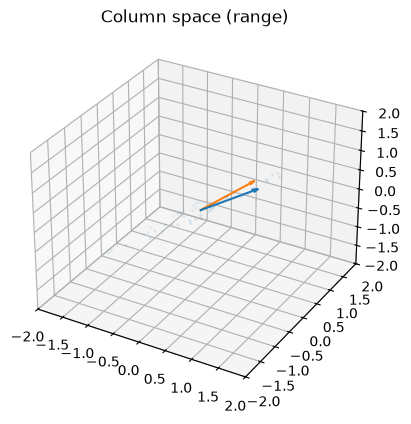

In [54]:
def column_space_3d(A, num=50):
    # A is 3xn
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    # Plot column vectors
    for i in range(A.shape[1]):
        ax.quiver(0,0,0, A[0,i], A[1,i], A[2,i], arrow_length_ratio=0.1, color=f'C{i}')
    # Generate random linear combinations to see the plane
    coeffs = np.random.uniform(-1, 1, (num, A.shape[1]))
    pts = coeffs @ A.T
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], alpha=0.3, s=2)
    ax.set_xlim(-2,2); ax.set_ylim(-2,2); ax.set_zlim(-2,2)
    ax.set_title('Column space (range)')
    plt.show()

# Example: 3x2 matrix -> plane in 3D
A_3x2 = np.array([[1, 0.5],
                  [0.2, 1],
                  [0.8, 0.3]])
column_space_3d(A_3x2)

Singular values: [5. 0.]
Null space basis vectors: [[-0.89442719  0.4472136 ]]


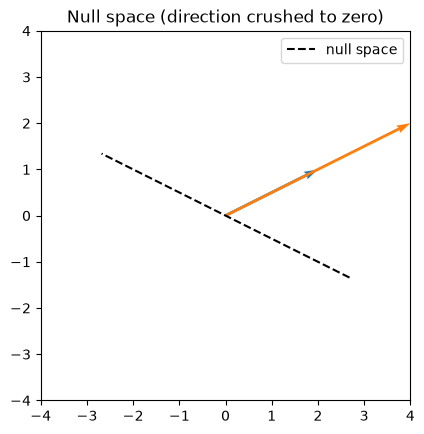

In [55]:
def null_space_2d(A):
    # Find null space basis using SVD
    U, s, Vt = np.linalg.svd(A)
    tol = 1e-10
    null_mask = s < tol
    null_basis = Vt[null_mask]  # rows of Vt that correspond to zero singular values
    print("Singular values:", s)
    print("Null space basis vectors:", null_basis)
    
    fig, ax = plt.subplots()
    # Plot columns
    for i in range(A.shape[1]):
        ax.quiver(0,0, A[0,i], A[1,i], angles='xy', scale_units='xy', scale=1, color=f'C{i}')
    # Plot null space line
    if len(null_basis) > 0:
        for v in null_basis:
            # Draw line in both directions
            t = np.linspace(-3, 3, 2)
            ax.plot(t*v[0], t*v[1], 'k--', label='null space')
    ax.set_xlim(-4,4); ax.set_ylim(-4,4); ax.set_aspect('equal')
    ax.legend()
    ax.set_title('Null space (direction crushed to zero)')
    plt.show()

A_sing = np.array([[2, 4],
                   [1, 2]])
null_space_2d(A_sing)

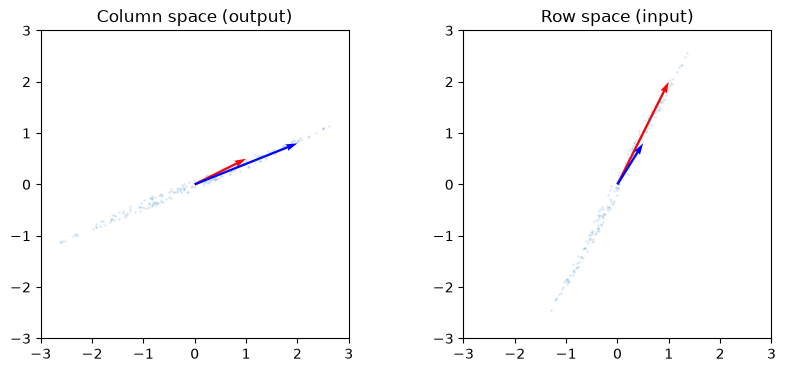

In [56]:
def row_vs_col_space(A):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
    # Column space
    col1, col2 = A[:,0], A[:,1]
    ax1.quiver(0,0, col1[0], col1[1], angles='xy', scale_units='xy', scale=1, color='r')
    ax1.quiver(0,0, col2[0], col2[1], angles='xy', scale_units='xy', scale=1, color='b')
    # generate span
    coeffs = np.random.uniform(-1,1,(200,2))
    pts = coeffs @ np.array([col1, col2])
    ax1.scatter(pts[:,0], pts[:,1], alpha=0.1, s=1)
    ax1.set_title('Column space (output)')
    ax1.set_xlim(-3,3); ax1.set_ylim(-3,3); ax1.set_aspect('equal')
    
    # Row space (columns of A^T)
    row1, row2 = A[0,:], A[1,:]   # or A.T columns
    ax2.quiver(0,0, row1[0], row1[1], angles='xy', scale_units='xy', scale=1, color='r')
    ax2.quiver(0,0, row2[0], row2[1], angles='xy', scale_units='xy', scale=1, color='b')
    pts_row = coeffs @ np.array([row1, row2])
    ax2.scatter(pts_row[:,0], pts_row[:,1], alpha=0.1, s=1)
    ax2.set_title('Row space (input)')
    ax2.set_xlim(-3,3); ax2.set_ylim(-3,3); ax2.set_aspect('equal')
    plt.show()

A = np.array([[1, 2],
              [0.5, 0.8]])
row_vs_col_space(A)